<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/02_classification/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart City Mobility: Predicting Surge Demand (Classification)

**Objective:** Shift from predicting exact bike counts to classifying whether a specific hour will experience "Surge Demand" (High traffic).
**Algorithm:** Logistic Regression (Baseline Classification)

In this notebook, we will:
1. Load and clean the UCI Seoul Bike dataset.
2. **Feature Engineering:** Create a new binary target variable (`Is_Surge`).
3. Preprocess and scale the data.
4. Train a Logistic Regression model to classify demand states.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
df = pd.read_csv(url, encoding='ISO-8859-1')

# Clean column names
df.columns = ['Date', 'Rented_Bike_Count', 'Hour', 'Temperature_C', 'Humidity_pct',
              'Wind_Speed_ms', 'Visibility_10m', 'Dew_Point_C', 'Solar_Radiation_MJm2',
              'Rainfall_mm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']

# Convert Date and extract features
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df = df.drop('Date', axis=1)

print("Data loaded and cleaned successfully!")

Data loaded and cleaned successfully!


## Feature Engineering: Creating the 'Surge' Target
To perform classification, we need categories. We will define **"Surge Demand"** as any hour where the number of rented bikes exceeds 1,000.

We will create a new column called `Is_Surge`:
* **1 (Yes):** Demand > 1000 bikes
* **0 (No):** Demand <= 1000 bikes

After this, we will drop the original `Rented_Bike_Count` column so the model doesn't use the answer to cheat!

In [2]:
# Define the threshold for a surge
surge_threshold = 1000

# Create the new binary target column using numpy's where function
df['Is_Surge'] = np.where(df['Rented_Bike_Count'] > surge_threshold, 1, 0)

# Drop the original continuous variable to prevent data leakage
df_class = df.drop('Rented_Bike_Count', axis=1)

# Check the balance of our new classes
class_counts = df_class['Is_Surge'].value_counts()
print("--- Class Distribution ---")
print(f"Normal Demand (0): {class_counts[0]} hours")
print(f"Surge Demand (1):  {class_counts[1]} hours")

display(df_class.head())

--- Class Distribution ---
Normal Demand (0): 6342 hours
Surge Demand (1):  2418 hours


,Hour,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_10m,Dew_Point_C,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Seasons,Holiday,Functioning_Day,Month,DayOfWeek,Is_Surge
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0


## 3. Visualizing the Classes
Before training, let's see if there is a visible difference between Normal and Surge hours based on weather. We will use a boxplot to compare the temperature distributions for both categories.

/tmp/ipykernel_775/478766116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Surge', y='Temperature_C', data=df_class, palette='Set2')


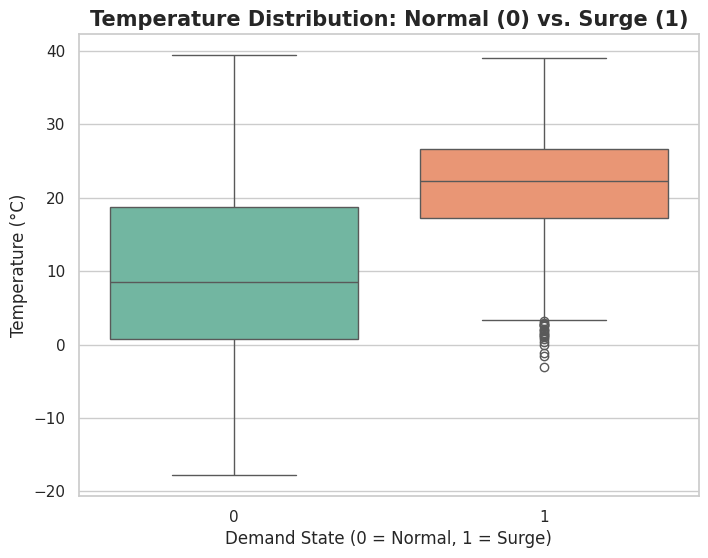

In [3]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is_Surge', y='Temperature_C', data=df_class, palette='Set2')

plt.title('Temperature Distribution: Normal (0) vs. Surge (1)', fontsize=15, fontweight='bold')
plt.xlabel('Demand State (0 = Normal, 1 = Surge)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.show()

## Explanation






*   Normal Demand (0 - Green Box): The temperature range for normal hours is massive, stretching all the way from -18°C up to nearly 40°C. The median temperature sits quite low, right around 8°C to 9°C.

*   Surge Demand (1 - Orange Box): The surge box is much tighter and sits significantly higher on the y-axis. The median temperature during a surge is a very comfortable 22°C to 23°C.
*   The Outliers: Notice the little circles at the bottom of the orange Surge box. Those are outliers. It proves that a surge in bike rentals almost never happens when it drops below 5°C.






## 4. Preprocessing for Logistic Regression
Logistic Regression is a linear model, but it wraps the linear equation in a **Sigmoid function** to squash the output into a probability between 0 and 1:
$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \dots + \beta_nx_n)}}$$

Just like Linear Regression, it requires all text to be converted to numbers, and all features to be scaled.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df_class, columns=['Seasons', 'Holiday', 'Functioning_Day'], drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('Is_Surge', axis=1)
y = df_encoded['Is_Surge']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data encoded, split, and scaled successfully!")

Data encoded, split, and scaled successfully!


## 5. Training the Model
We will train the `LogisticRegression` model. Since our dataset is imbalanced (more normal hours than surge hours), we will use `class_weight='balanced'`. This mathematically forces the algorithm to pay extra attention to the minority class (Surge hours) so it doesn't just lazily predict "Normal" every time.

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize the model with balanced class weights
log_model = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model successfully trained!")

Logistic Regression model successfully trained!


## 6. Evaluation: The Confusion Matrix
In classification, accuracy isn't enough. We need to see exactly where the model is making mistakes. A Confusion Matrix shows us:
*   **True Positives:** Predicted Surge, and it WAS a Surge.
*   **True Negatives:** Predicted Normal, and it WAS Normal.
*   **False Positives (Type I Error):** Predicted Surge, but it was Normal.
*   **False Negatives (Type II Error):** Predicted Normal, but it was a Surge.

<Figure size 600x600 with 0 Axes>

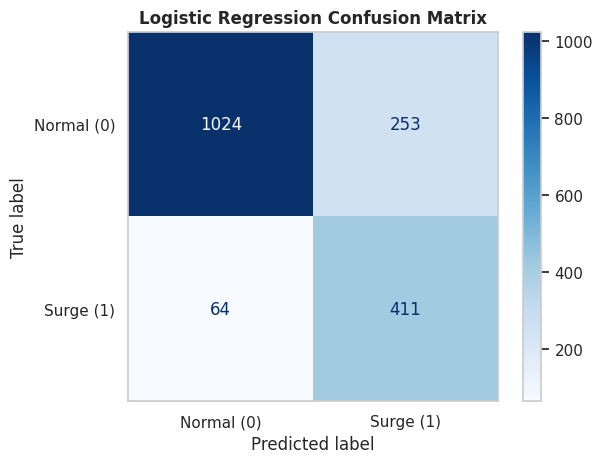


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      1277
           1       0.62      0.87      0.72       475

    accuracy                           0.82      1752
   macro avg       0.78      0.83      0.79      1752
weighted avg       0.85      0.82      0.83      1752



In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot the confusion matrix beautifully
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Surge (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression Confusion Matrix', fontweight='bold')
plt.grid(False) # Hides grid lines on the matrix
plt.show()

# Print the detailed classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_log))

## From the Confusion Matrix above:
Top Left (1024 - True Negatives): The model correctly predicted a Normal hour.

Bottom Right (411 - True Positives): The model correctly predicted a Surge hour.

Bottom Left (64 - False Negatives): The model predicted Normal, but it was actually a Surge. (It missed the surge completely).

Top Right (253 - False Positives): The model predicted a Surge, but it was actually a Normal hour. (A false alarm).

# Part 2: Decision Tree Analysis (Tree-Based Classification)

Objective: Transition from the statistical Logistic Regression model to a recursive splitting approach using Decision Trees. We will evaluate if a logic-based model can outperform our baseline.

**Strategy:**
1. **Initial overfitted tree:** We will train the model with default parameters, deliberately letting it grow unrestricted to visualize how trees can "learn the noise" of a dataset (as warned in our intro post).
2. **Visualization:** We will generate the classic "tree flow chart" and visualize Feature Importance.
3. **Pruning/Tuning:** We will use hyperparameter tuning to find the optimal size of the tree.

In [7]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the DecisionTreeClassifier.
# We use the default settings (no max depth) to deliberately overfit the training data first.
# We keep random_state=42 for consistency.
dt_initial = DecisionTreeClassifier(random_state=42)

# 2. Train the model using the SAME scaled training data as Logistic Regression
dt_initial.fit(X_train_scaled, y_train)

print("Initial (unrestricted) Decision Tree model successfully trained!")

Initial (unrestricted) Decision Tree model successfully trained!


## 8. Evaluating the Initial Tree
We will generate the confusion matrix and classification report for this unconstrained tree. We are looking for signs of extreme overfitting (near-perfect scores on training data, unstable scores on testing data).

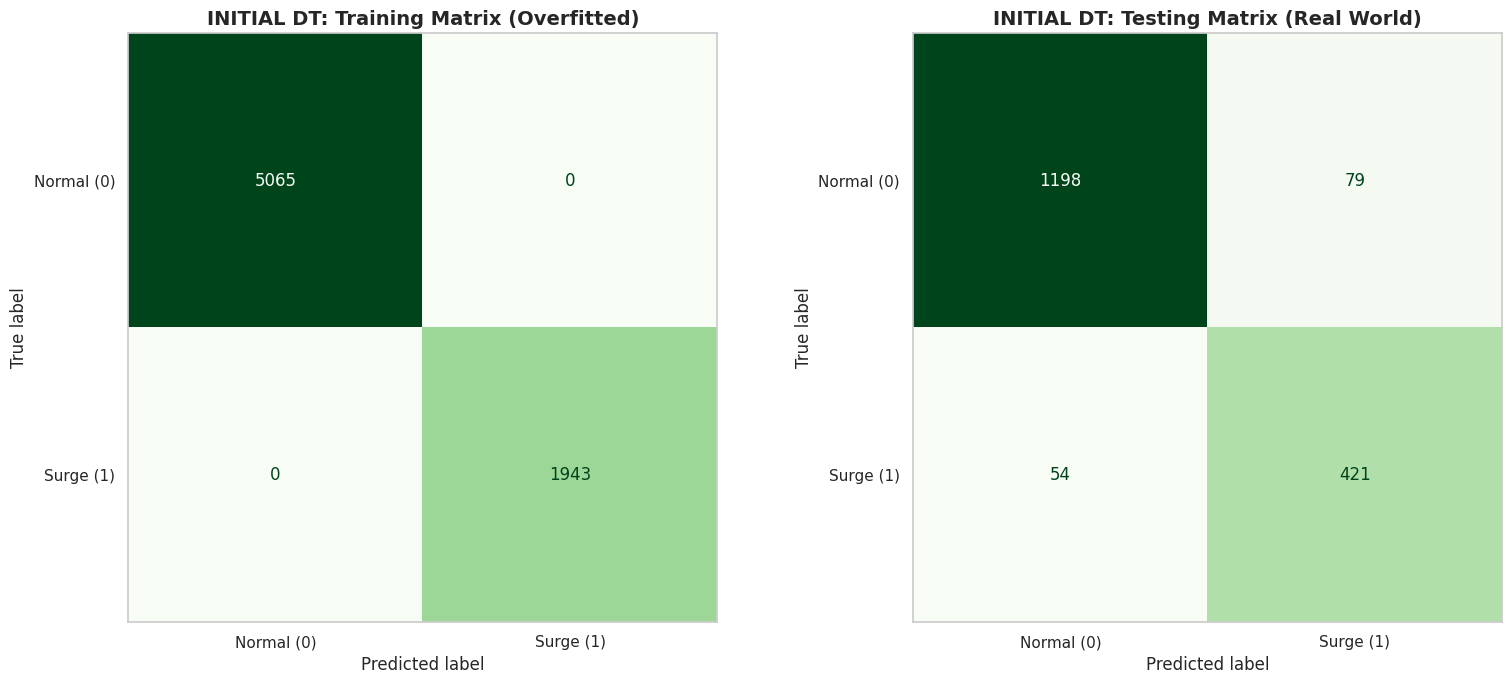


--- INITIAL DT: Testing Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1277
           1       0.84      0.89      0.86       475

    accuracy                           0.92      1752
   macro avg       0.90      0.91      0.91      1752
weighted avg       0.93      0.92      0.92      1752



In [8]:
# Make predictions on BOTH training and testing sets
y_pred_train_dt = dt_initial.predict(X_train_scaled)
y_pred_test_dt = dt_initial.predict(X_test_scaled)

# Setup subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Training Confusion Matrix (Deliberate Overfit)
cm_train = confusion_matrix(y_train, y_pred_train_dt)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Normal (0)', 'Surge (1)'])
disp_train.plot(cmap='Greens', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title('INITIAL DT: Training Matrix (Overfitted)', fontweight='bold', fontsize=14)
axes[0].grid(False)

# Plot 2: Testing Confusion Matrix (Real Performance)
cm_test = confusion_matrix(y_test, y_pred_test_dt)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Normal (0)', 'Surge (1)'])
disp_test.plot(cmap='Greens', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title('INITIAL DT: Testing Matrix (Real World)', fontweight='bold', fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Print the detailed testing classification report for comparison with LogReg
print("\n--- INITIAL DT: Testing Classification Report ---")
print(classification_report(y_test, y_pred_test_dt))

## Explaining the results
Proof of Absolute Overfitting (The Training Matrix): Look at the matrix on the left. It is flawless. It shows 5065 perfect normal predictions, 1943 perfect surge predictions, and zero errors. The Decision Tree essentially asked a specific, dedicated question for every single hour in the training data, memorizing its label. This is the definition of overfitting.

The Testing Paradox: Normally, when you overfit this aggressively on the training data, your testing performance collapses. It fails to generalize. However, your Decision Tree actually beat our Logistic Regression baseline on almost every metric!

Let’s compare the testing performance (Class 1 - Surge):

Logistic Regression baseline: Recall 87% | Precision 62%.

Overfitted Decision Tree: Recall 89% | Precision 84%.

This unrestricted tree is significantly more stable and accurate than our baseline.

The Takeaway: This provides strong evidence that the underlying logic driving bike demand in Seoul is deeply non-linear. The rigid statistical lines and probability curves of Logistic Regression struggle to find the clean boundary, whereas the intuitive, logic-based splits of the Decision Tree are finding the true pattern, even when allowed to memorize the data noise.

## 9. Visualizing the Overfitted Tree and Feature Importance
Our unconstrained Decision Tree is incredibly accurate (outperforming the Logistic Regression baseline), but it is a black box. We cannot visualize it properly as it has hundreds, perhaps thousands, of tiny decision nodes and extreme split rules.

We will prove this complexity first, and then visualize **Feature Importance** to identify which variables are truly driving the predictions.

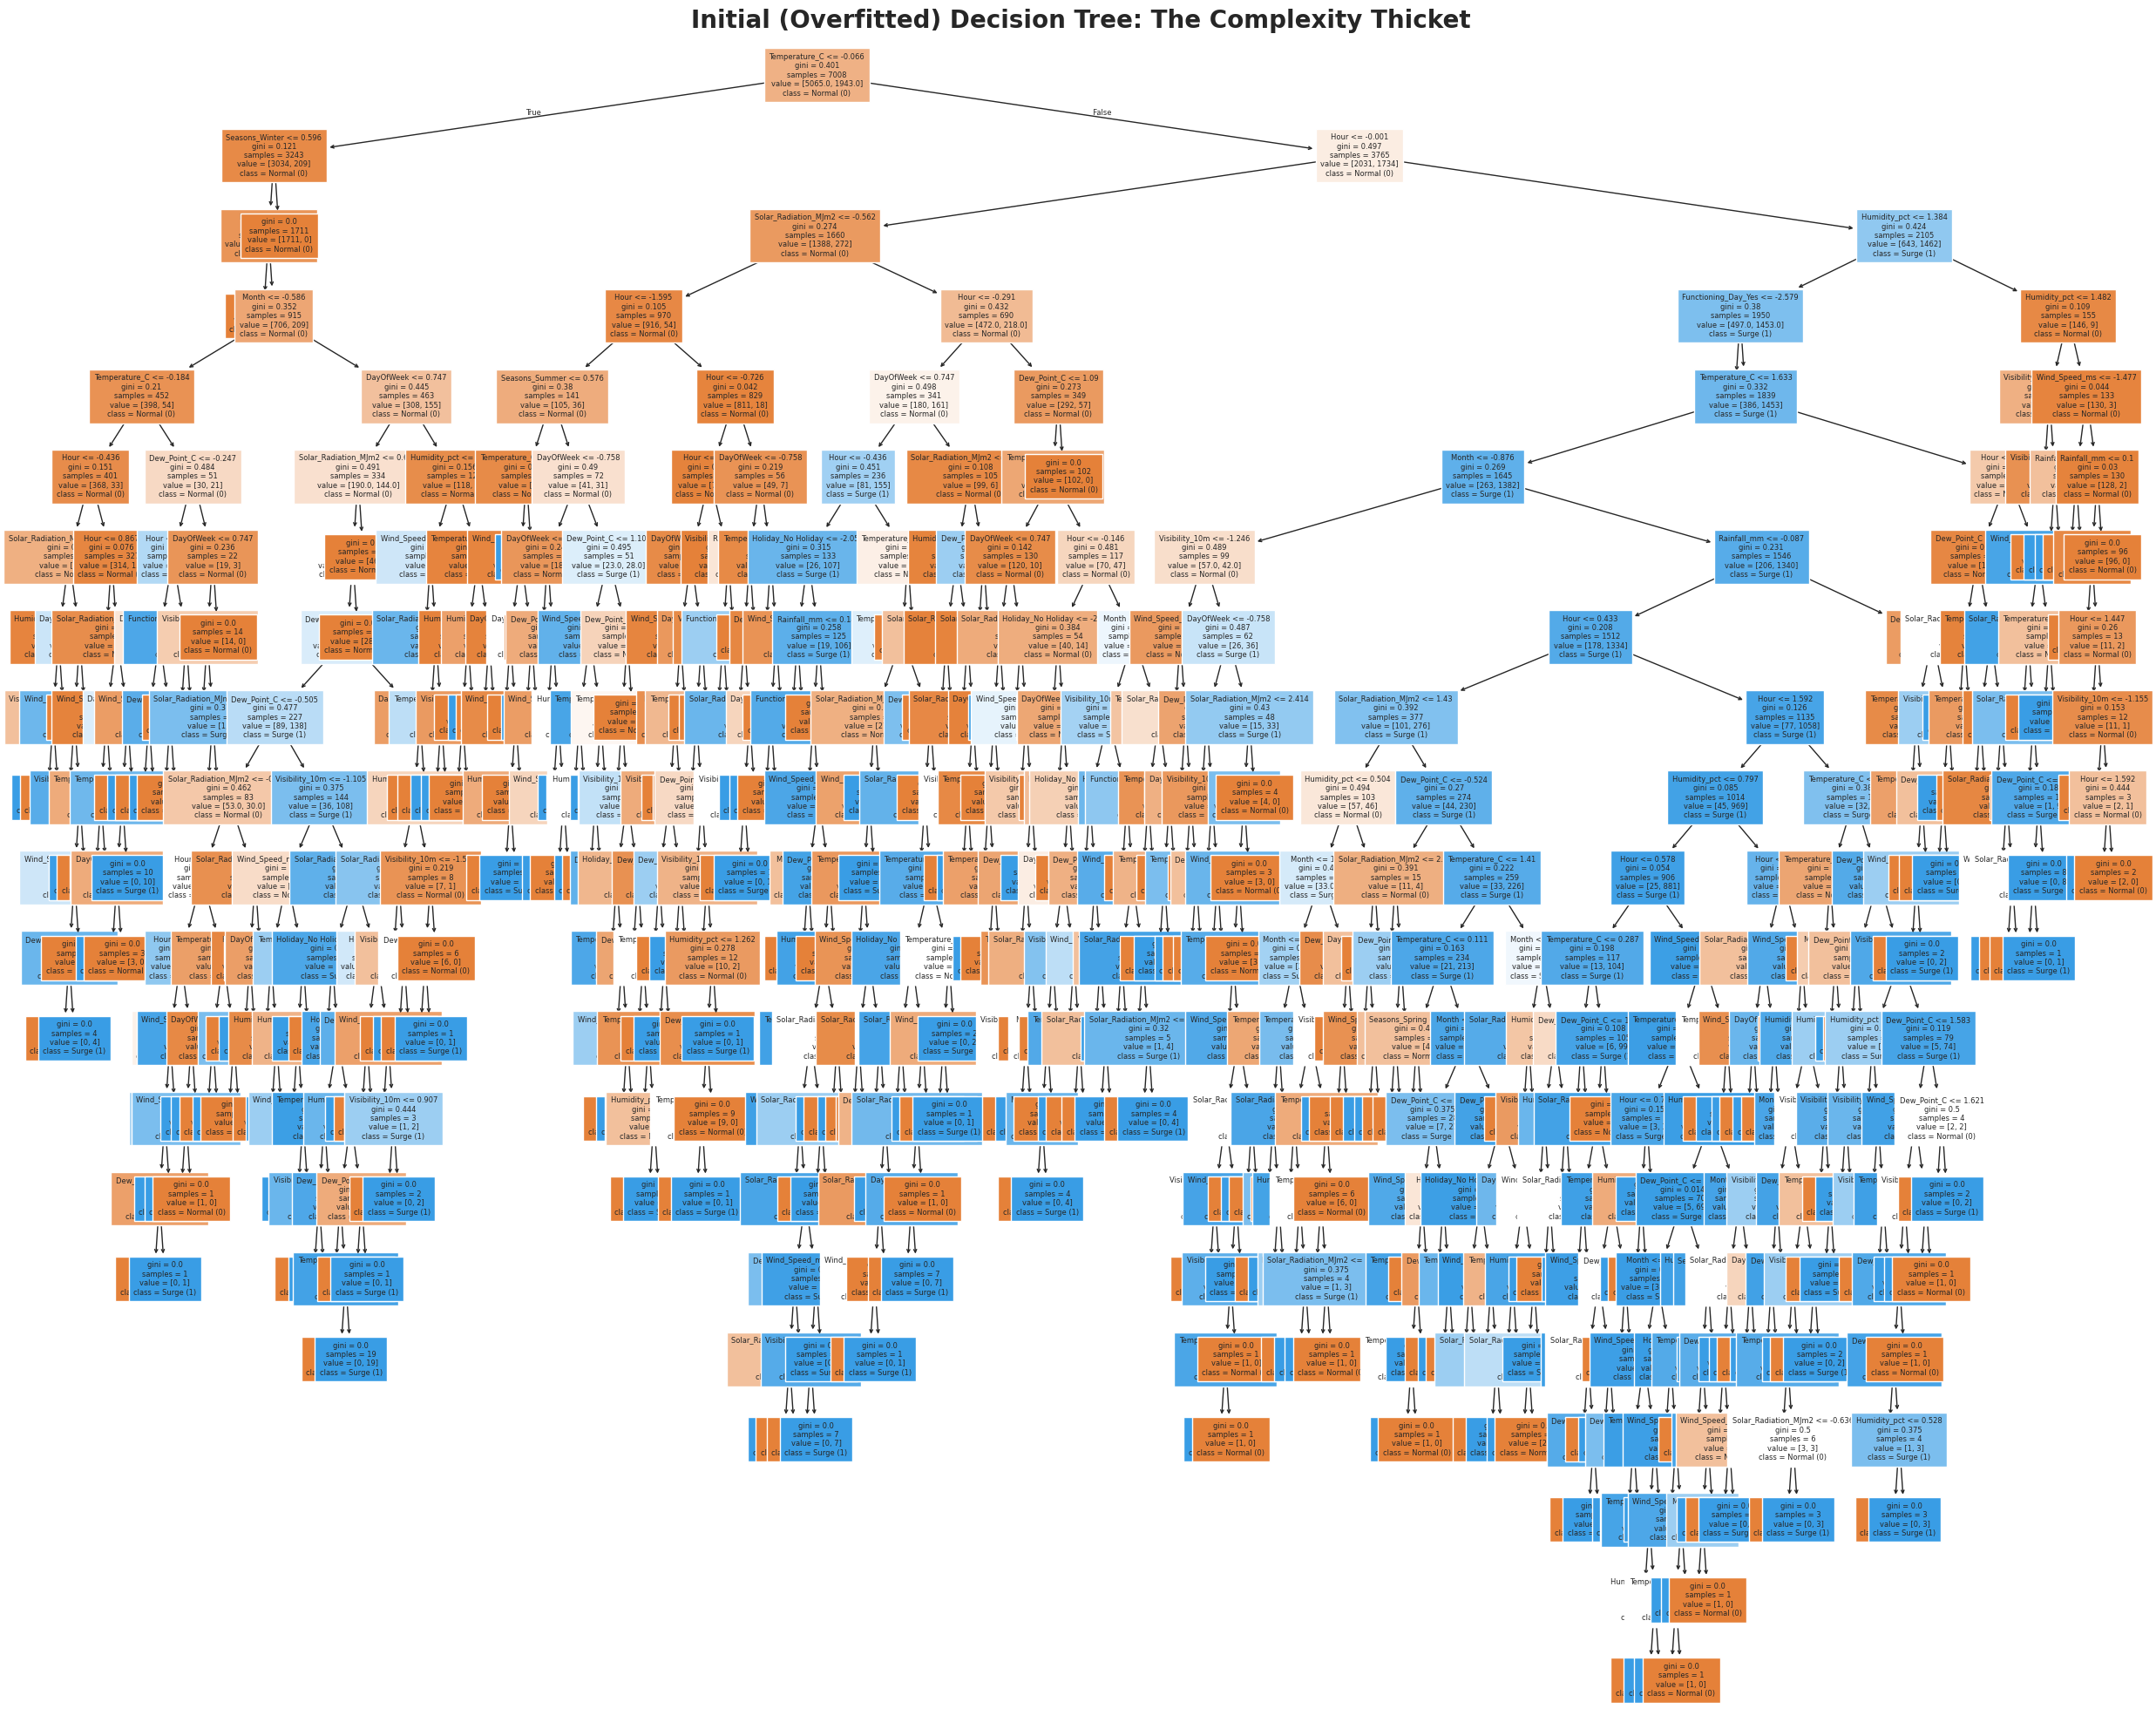


--- Model Complexity ---
The initial overfitted tree has a massive depth of 20 levels!
This tree is a chaotic thicket that has memorized the training data noise, making it uninterpretable.


In [9]:
from sklearn.tree import plot_tree

# 1. Attempt to plot the entire unconstrained tree
# For a professional portfolio, we set the plot size incredibly large, and even that is likely too small.
plt.figure(figsize=(25, 20))
plot_tree(dt_initial,
          feature_names=list(X.columns),
          class_names=['Normal (0)', 'Surge (1)'],
          filled=True,
          fontsize=6) # Set very small fontsize
plt.title("Initial (Overfitted) Decision Tree: The Complexity Thicket", fontweight='bold', fontsize=20)
plt.tight_layout()
plt.show()

# 2. Check the depth to confirm complexity
depth = dt_initial.get_depth()
print(f"\n--- Model Complexity ---")
print(f"The initial overfitted tree has a massive depth of {depth} levels!")
print("This tree is a chaotic thicket that has memorized the training data noise, making it uninterpretable.")

/tmp/ipykernel_775/2103600355.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')


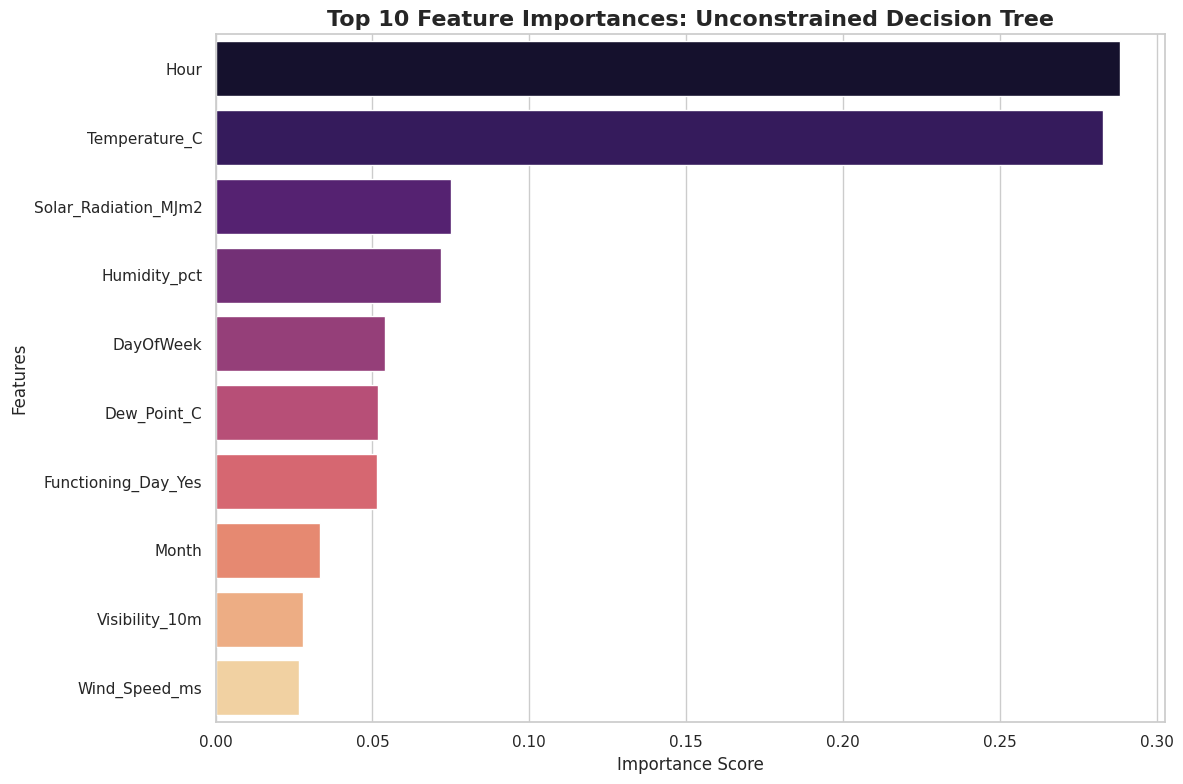

,Feature,Importance
0,Hour,0.288330
1,Temperature_C,0.282746
2,Solar_Radiation_MJm2,0.075079
3,Humidity_pct,0.071791
4,DayOfWeek,0.053913
5,Dew_Point_C,0.051819
6,Functioning_Day_Yes,0.051357
7,Month,0.033372
8,Visibility_10m,0.027873
9,Wind_Speed_ms,0.026701


In [10]:
# Create a DataFrame for Feature Importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_initial.feature_importances_
})

# Sort the results by importance, highest at the top
importances = importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Visualize the Top 10 Features
plt.figure(figsize=(12, 8))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Feature Importances: Unconstrained Decision Tree', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

display(importances.head(10))

# Breaking Down the Feature Importance
In our linear and logistic regression models, Temperature was consistently the dominant force. But look at your chart: Hour (0.288) has officially dethroned Temperature (0.282) to become the number one driver of bike surges.

Why did this happen?

Linear models struggle with time. The relationship between time and demand is non-linear. Demand spikes at 8:00 AM, drops at noon, and spikes again at 5:00 PM. A straight mathematical line cannot easily follow that W-shaped curve.

Trees love time. A Decision Tree doesn't care about straight lines. It can easily say, "If Hour == 8 OR Hour == 17, then SURGE." It perfectly captures those exact commuter rush hours, which is exactly why this tree outperformed our Logistic Regression baseline

# Part 3: HYPERPARAMETER TUNING (Pruning)

Objective: Tune the Decision Tree hyperparameters to find the optimal balance between high predictive accuracy and long-term model stability (interpretability).

We will use **Grid Search (`GridSearchCV`)** to systematically test combinations of two key "surgical dials":
1. **`max_depth` (The Height Limit):** We want to constrain how deep (complex) the tree grows.
2. **`min_samples_split` (The Crowd Rule):** We only allow a new split if a sufficient number of data samples follow the pattern.

In [11]:
from sklearn.model_selection import GridSearchCV

# 1. Initialize a generic Decision Tree (retaining balanced weights for fairness)
# We keep random_state=42 for consistency.
dt_generic = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Define the "Menu" of Hyperparameters to test (The Parameter Grid)
# GridSearchCV will brute-force test every single combination here.
param_grid = {
    # Test Max Depths: 3 (Very simple) to 8 (Getting complex)
    'max_depth': [3, 4, 5, 6, 7, 8],

    # Test Min Samples to Split: 20 (Allows specific rules) to 200 (Forces universal rules)
    'min_samples_split': [20, 50, 100, 150, 200],

    # Optional: Test Min Samples per Leaf node (Prevents leaves with 1 outlier)
    'min_samples_leaf': [10, 20, 30]
}

# 3. Initialize GridSearchCV (The Automated Surgical Robot)
# - scoring='f1': Optimizes for a balance of Precision AND Recall.
# - cv=5: Performs 5-fold Cross-Validation for result stability.
grid_search = GridSearchCV(estimator=dt_generic,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           verbose=1, # Prints progress
                           n_jobs=-1) # Uses all CPU cores for speed

# 4. Perform the surgery: Scan the grid to find the best tree
print("Beginning GridSearchCV... this may take a moment to scan hundreds of combinations.")
grid_search.fit(X_train_scaled, y_train)

# 5. Extract the Results
print("\n--- Surgical Success! ---")
print(f"Best cross-validated F1 score found: {grid_search.best_score_:.4f}")
print("Optimal Hyperparameters (The Pruning Recipe):")
print(grid_search.best_params_)

# 6. Save the newly optimized, pruned model
final_pruned_model = grid_search.best_estimator_

Beginning GridSearchCV... this may take a moment to scan hundreds of combinations.
Fitting 5 folds for each of 90 candidates, totalling 450 fits

--- Surgical Success! ---
Best cross-validated F1 score found: 0.8338
Optimal Hyperparameters (The Pruning Recipe):
{'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 20}


## 10. Evaluating the Optimized Model
We will generate a Confusion Matrix and Classification Report for our pruned tree (`final_pruned_model`) and compare it against our Logistic Regression baseline.

<Figure size 600x600 with 0 Axes>

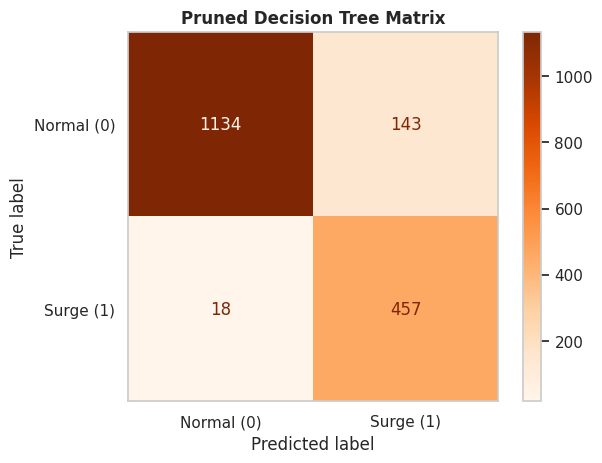


--- PRUNED DT: Final Testing Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      1277
           1       0.76      0.96      0.85       475

    accuracy                           0.91      1752
   macro avg       0.87      0.93      0.89      1752
weighted avg       0.92      0.91      0.91      1752



In [12]:
# Make predictions using the optimized model
y_pred_pruned = final_pruned_model.predict(X_test_scaled)

# Generate the confusion matrix
cm_pruned = confusion_matrix(y_test, y_pred_pruned)

# Plot the confusion matrix beautifully
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pruned, display_labels=['Normal (0)', 'Surge (1)'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Pruned Decision Tree Matrix', fontweight='bold')
plt.grid(False)
plt.show()

# Print the detailed classification report
print("\n--- PRUNED DT: Final Testing Classification Report ---")
print(classification_report(y_test, y_pred_pruned))

## The Confusion Matrix: A Massive Operations Win
Look at the bottom row of our matrix. Out of 475 actual surges, our pruned model successfully caught 457 of them.

Recall skyrocketed to 96%: It only missed 18 surges in the entire testing set. For a city fleet management team, this means practically zero empty stations and no stranded commuters.

Precision stabilized at 76%: It threw 143 false alarms. This is significantly fewer false alarms than your Logistic Regression baseline (which had 253).

The Verdict: we built a highly sensitive early-warning system that is far more efficient than your statistical baseline.

## 11. Visualizing the Interpretable Logic
Unlike our unconstrained thicket, this tree is pruned. We will plot the top 3 levels to demonstrate how city fleet managers can read the exact logic driving the predictive engine.

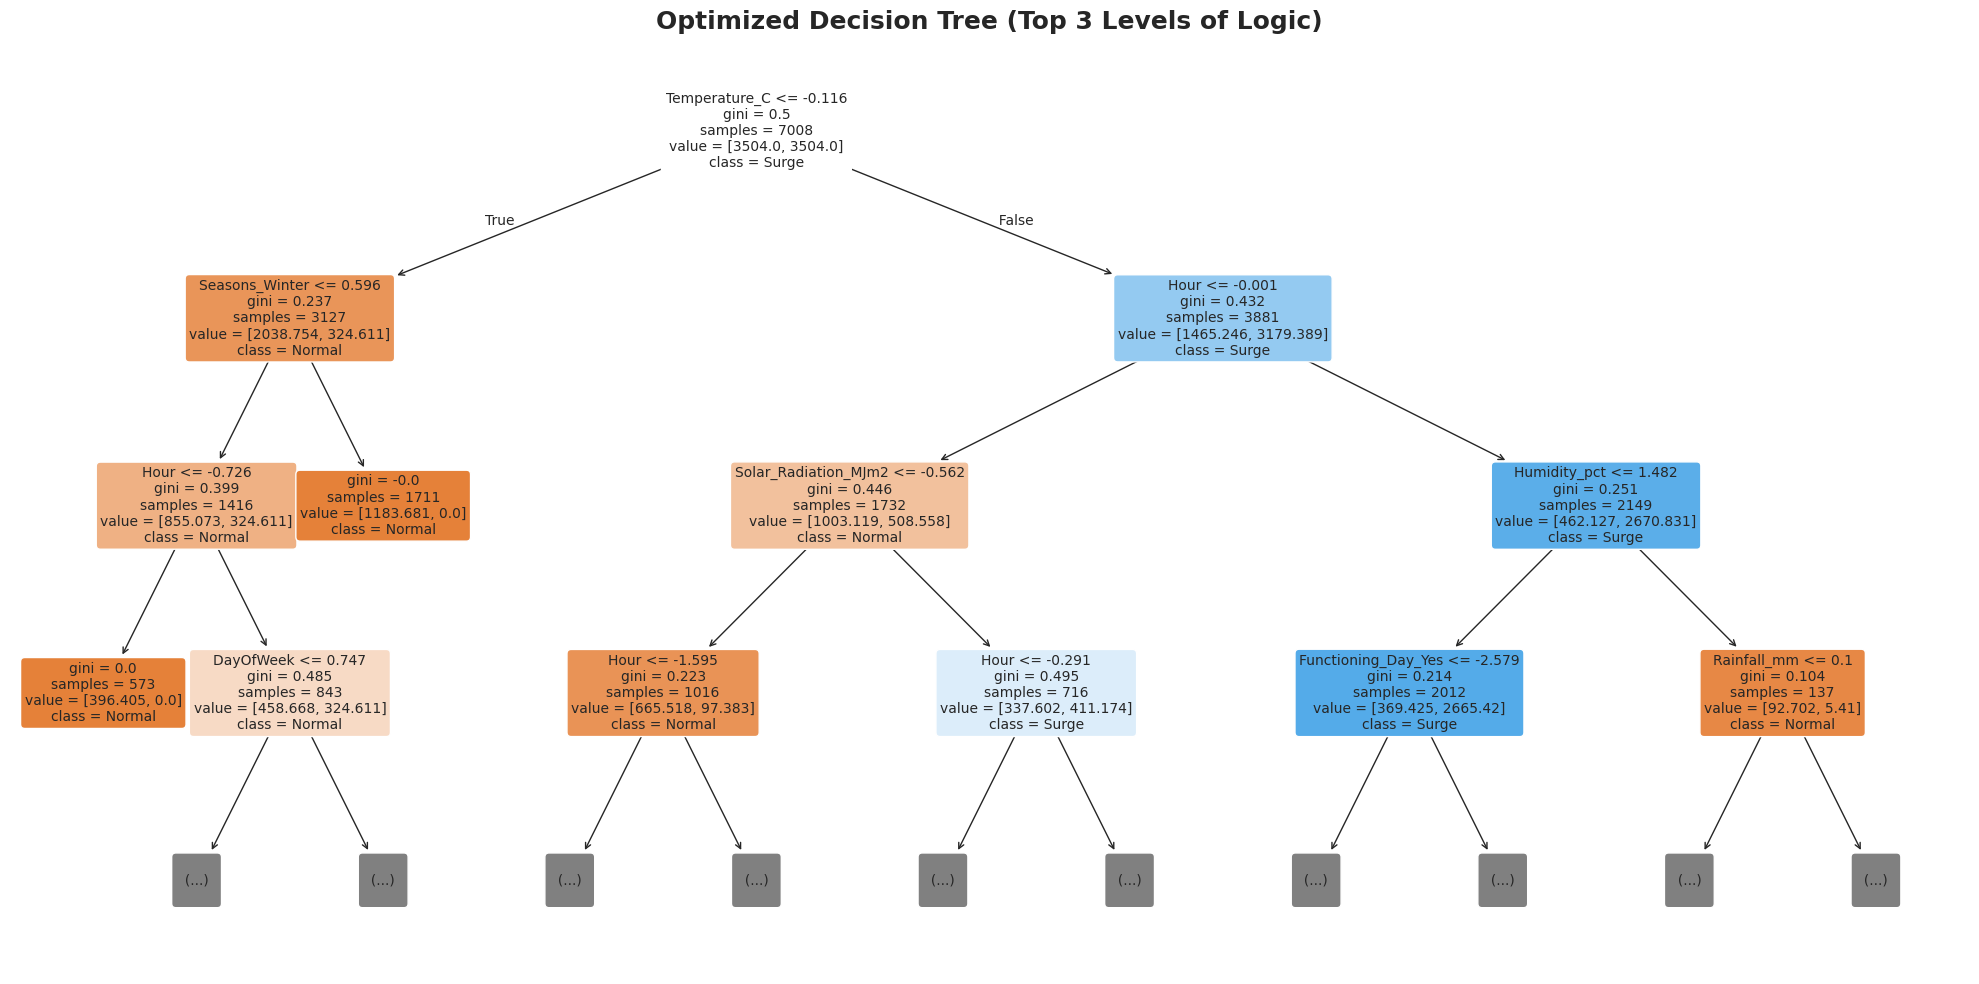

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

# We set max_depth=3 just for the visual, so the boxes are large enough to read easily
plot_tree(final_pruned_model,
          max_depth=3,
          feature_names=list(X.columns),
          class_names=['Normal', 'Surge'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Optimized Decision Tree (Top 3 Levels of Logic)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## The Tree Logic: Interpretable and Beautiful
Look at our top 3 levels. Because we scaled our data earlier, the numbers in the boxes are standard deviations, but the logic is perfectly clear:

The Root Split: The very first question the tree asks is about Temperature.

The Left Branch (Colder): If the temperature is low, the very next thing the tree checks is if it is Winter.

The Right Branch (Warmer): If the temperature is higher, the very next thing it checks is the Hour (looking for commuter rush hours).

This is no longer a black box. A fleet manager can trace this flowchart with their finger and understand exactly why the algorithm is predicting a surge.

# Part 4: Ensemble Learning (Random Forest)

Objective: Upgrade from a single Decision Tree to a Random Forest. By training 100 individual trees on random subsets of data and features, we aim to use the "Wisdom of the Crowd" to maximize predictive stability and accuracy.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest
# n_estimators=100: We are building a "board of directors" with 100 individual trees.
# class_weight='balanced': We still need to force the model to pay attention to the minority Surge hours.
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train the ensemble on our scaled training data
rf_model.fit(X_train_scaled, y_train)

print("Random Forest (100 trees) successfully trained!")

Random Forest (100 trees) successfully trained!


<Figure size 600x600 with 0 Axes>

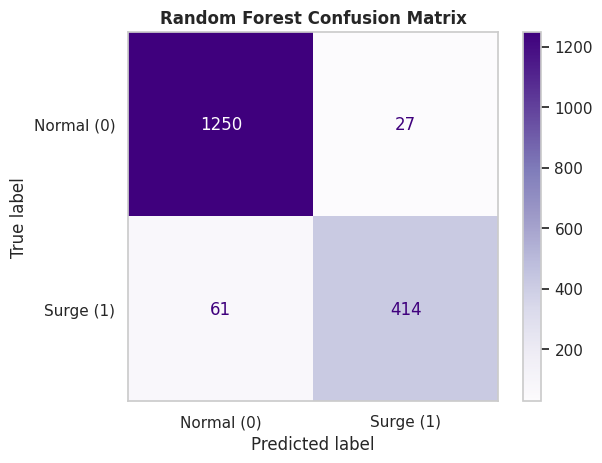


--- RANDOM FOREST: Final Testing Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1277
           1       0.94      0.87      0.90       475

    accuracy                           0.95      1752
   macro avg       0.95      0.93      0.93      1752
weighted avg       0.95      0.95      0.95      1752



In [15]:
# Make predictions using the Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix beautifully
plt.figure(figsize=(6, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Normal (0)', 'Surge (1)'])
disp_rf.plot(cmap='Purples', values_format='d')
plt.title('Random Forest Confusion Matrix', fontweight='bold')
plt.grid(False)
plt.show()

# Print the detailed classification report
print("\n--- RANDOM FOREST: Final Testing Classification Report ---")
print(classification_report(y_test, y_pred_rf))

## The Random Forest Shift: Precision over Recall
Massive Reduction in False Alarms: Look at the top right of your matrix. The Random Forest only threw 27 false alarms, compared to the pruned Decision Tree's 143.

Precision Skyrocketed (94%): Because it threw so few false alarms, your precision jumped from 76% to an incredible 94%. When the Random Forest predicts a surge, you can trust it almost completely.

The Trade-off (Lower Recall at 87%): The "Board of Directors" is highly conservative. Because 100 trees have to vote, they are less likely to cry wolf. The penalty? They completely missed 61 actual surges (bottom left), whereas your single pruned tree only missed 18 (96% recall).